In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from peft import AdaLoraConfig,get_peft_model

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.9 MB/s eta 0:00:00
Mounted at /content/drive


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load Yelp dataset
file_path = "/content/drive/MyDrive/Yelp Reviews.csv"

df = pd.read_csv(
    file_path,
    encoding='ISO-8859-1'
)

# Keep required columns only
df = df[['Text', 'Sentiment']].dropna()

total_instances = len(df)

print(f"Total instances: {total_instances}")
print("\nOriginal sentiment distribution:")
print(df['Sentiment'].value_counts().sort_index())


# Convert Yelp 5 ratings -> 3 sentiment classes
# 1,2 = Negative
# 3   = Neutral
# 4,5 = Positive

def convert_to_3_classes(sentiment):

    if sentiment in [1, 2]:
        return 0   # Negative

    elif sentiment == 3:
        return 1   # Neutral

    else:
        return 2   # Positive


df['label'] = df['Sentiment'].apply(convert_to_3_classes)

print("\nNumber of instances per label:")
print(df['label'].value_counts().sort_index())

# Split data
train_texts, temp_texts, train_labels, temp_labels = train_test_split(

    df['Text'].tolist(),
    df['label'].tolist(),

    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(

    temp_texts,
    temp_labels,

    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(
    f"\nTrain size: {len(train_texts)} | "
    f"Val size: {len(val_texts)} | "
    f"Test size: {len(test_texts)}"
)

# Optional sanity check
print("\nTrain label distribution:")
print(pd.Series(train_labels).value_counts().sort_index())

print("\nValidation label distribution:")
print(pd.Series(val_labels).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(test_labels).value_counts().sort_index())

Total instances: 6871

Original sentiment distribution:
Sentiment
0    1204
1    1522
2    1591
3    1398
4    1156
Name: count, dtype: int64

Number of instances per label:
label
0    3113
1    1398
2    2360
Name: count, dtype: int64

Train size: 5496 | Val size: 687 | Test size: 688

Train label distribution:
0    2490
1    1118
2    1888
Name: count, dtype: int64

Validation label distribution:
0    311
1    140
2    236
Name: count, dtype: int64

Test label distribution:
0    312
1    140
2    236
Name: count, dtype: int64


In [17]:
model_name="roberta-base"

tokenizer=AutoTokenizer.from_pretrained(
    model_name
)

train_enc=tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_enc=tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_enc=tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)


class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self,encodings,labels):

        self.encodings=encodings
        self.labels=labels

    def __getitem__(self,idx):

        return {

            k:torch.tensor(v[idx])

            for k,v in self.encodings.items()

        } | {

            'labels':torch.tensor(
                self.labels[idx]
            )
        }

    def __len__(self):

        return len(self.labels)


train_ds=ReviewDataset(
    train_enc,
    train_labels
)

val_ds=ReviewDataset(
    val_enc,
    val_labels
)

test_ds=ReviewDataset(
    test_enc,
    test_labels
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [18]:
def compute_metrics(eval_pred):

    logits,labels=eval_pred

    preds=np.argmax(
        logits,
        axis=1
    )

    acc=accuracy_score(
        labels,
        preds
    )*100


    prec,rec,f1,_=precision_recall_fscore_support(

        labels,
        preds,
        average='macro'
    )


    return {

        "Accuracy":acc,

        "Precision":prec*100,

        "Recall":rec*100,

        "F1 Score":f1*100
    }

In [20]:
model_name = "roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

adalora_cfg = AdaLoraConfig(

    task_type="SEQ_CLS",

    init_r=12,
    target_r=8,

    beta1=0.85,
    beta2=0.85,

    tinit=200,
    tfinal=1000,
    deltaT=10,

    lora_alpha=32,
    lora_dropout=0.1,

    target_modules=[
        "query",
        "key",
        "value"
    ]
)

model = get_peft_model(
    model,
    adalora_cfg
)

model.print_trainable_parameters()


args = TrainingArguments(

    output_dir="./adalora-roberta-yelp",

    evaluation_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    fp16=torch.cuda.is_available(),

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    save_total_limit=2
)


trainer = Trainer(

    model=model,

    args=args,

    train_dataset=train_ds,

    eval_dataset=val_ds,

    compute_metrics=compute_metrics
)

start = time.time()

train_output = trainer.train()

training_time = time.time() - start

metrics = trainer.evaluate(test_ds)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


trainable params: 1,256,883 || all params: 125,904,858 || trainable%: 0.9983


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,1.123600,0.732842,66.229985,64.473983,65.845265,64.727242
2,0.743200,0.701789,67.394469,65.659560,60.162342,60.167760
3,0.679300,0.690160,69.141194,66.173238,64.839553,64.939050
4,0.661400,0.685188,70.742358,68.361593,68.118504,67.884529
5,0.656700,0.667767,71.470160,68.621254,68.672472,68.611389


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

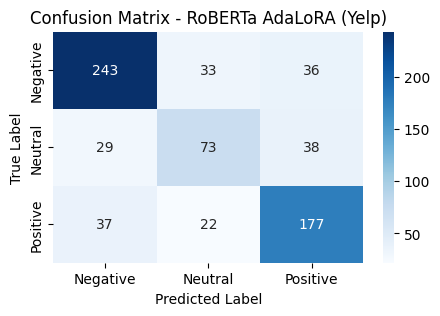

In [23]:
preds_out = trainer.predict(
    test_ds
)

preds = np.argmax(
    preds_out.predictions,
    axis=1
)

cm = confusion_matrix(
    test_ds.labels,
    preds,
    labels=[0,1,2]
)

plt.figure(figsize=(5,3))

sns.heatmap(

    cm,

    annot=True,
    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ],

    yticklabels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

plt.title(
    "Confusion Matrix - RoBERTa AdaLoRA (Yelp)"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

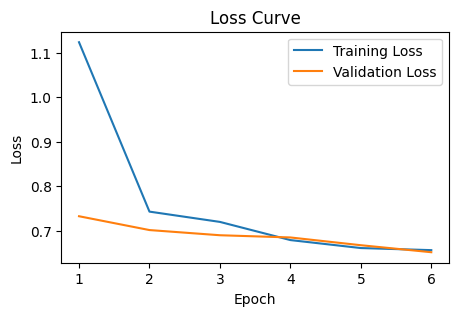

In [24]:
history=trainer.state.log_history


train_loss=[

    x["loss"]

    for x in history

    if "loss" in x
]


eval_loss=[

    x["eval_loss"]

    for x in history

    if "eval_loss" in x
]


plt.figure(figsize=(5,3))

plt.plot(
    range(1,len(train_loss)+1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1,len(eval_loss)+1),
    eval_loss,
    label="Validation Loss"
)

plt.title(
    "Loss Curve"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(False)

plt.show()

In [26]:
probs = torch.softmax(

    torch.tensor(
        preds_out.predictions
    ),

    dim=1
)

confidence = probs.max(
    dim=1
).values.numpy().mean() * 100


# One-hot encoding for 3 classes
labels_onehot = np.eye(
    3
)[test_ds.labels]


similarity = cosine_similarity(

    preds_out.predictions,
    labels_onehot

).mean() * 100


results = {

    "Model": "AdaLoRA RoBERTa",

    "Accuracy":
    f"{metrics['eval_Accuracy']:.2f}%",

    "Precision":
    f"{metrics['eval_Precision']:.2f}%",

    "Recall":
    f"{metrics['eval_Recall']:.2f}%",

    "F1 Score":
    f"{metrics['eval_F1 Score']:.2f}%",

    "Similarity":
    f"{similarity:.2f}%",

    "Confidence":
    f"{confidence:.2f}%",

    "Training Time (s)":
    f"{training_time:.2f}",

    "Trainable Params":
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ),

    "GPU Memory (GB)":
    f"{torch.cuda.max_memory_allocated()/1024**3:.4f}"
    if torch.cuda.is_available()
    else "N/A"
}


comparison_df = pd.DataFrame(
    [results]
)

print(
    comparison_df.to_string(index=False)
)

          Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA RoBERTa   71.66%    68.73% 68.34%   68.48%     -0.75%     76.44%            552.52           1256883          3.2804
